In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
print("Fist 10 rows of the dataset")
df.head(10)

Fist 10 rows of the dataset


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")


Dataset Shape: 545 rows and 13 columns


In [5]:
print("\nMissing Values Per Column")
print(df.isnull().sum())


Missing Values Per Column
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [6]:
# Checking is there any duplicate rows
duplicated_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicated_count}")

Number of duplicate rows found: 0


In [7]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns to encode: {list(categorical_cols)}")


Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [8]:
 # Applying One-Hot encoding

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

In [9]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [10]:
print("\n--- Shape of Data After Encoding ---")
print(f"{df_encoded.shape[0]} rows and {df_encoded.shape[1]} columns")


--- Shape of Data After Encoding ---
545 rows and 14 columns


In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Separate features (X) from our target variable (y)
X = df_encoded.drop('price', axis=1)  # Everything EXCEPT price
y = df_encoded['price']               # Just the price

# 2. Split the data into 80% training and 20% testing
# random_state=42 ensures we get the exact same split every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training with: {X_train.shape[0]} houses")
print(f"Testing with: {X_test.shape[0]} houses\n")

# 3. Model 1: Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)  # Training happens here
lr_preds = lr_model.predict(X_test)  # Testing happens here

# 4. Model 2: Train Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)  # Training happens here
rf_preds = rf_model.predict(X_test)  # Testing happens here

# 5. Helper function to print out evaluation metrics nicely
def print_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"=== {model_name} Results ===")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"R² Score (Accuracy): {r2:.4f}\n")

# Print the final showdown results!
print_metrics("Linear Regression", y_test, lr_preds)
print_metrics("Random Forest Regressor", y_test, rf_preds)

Training with: 436 houses
Testing with: 109 houses

=== Linear Regression Results ===
Mean Absolute Error (MAE): $970,043.40
Root Mean Squared Error (RMSE): $1,324,506.96
R² Score (Accuracy): 0.6529

=== Random Forest Regressor Results ===
Mean Absolute Error (MAE): $1,021,546.04
Root Mean Squared Error (RMSE): $1,400,565.97
R² Score (Accuracy): 0.6119



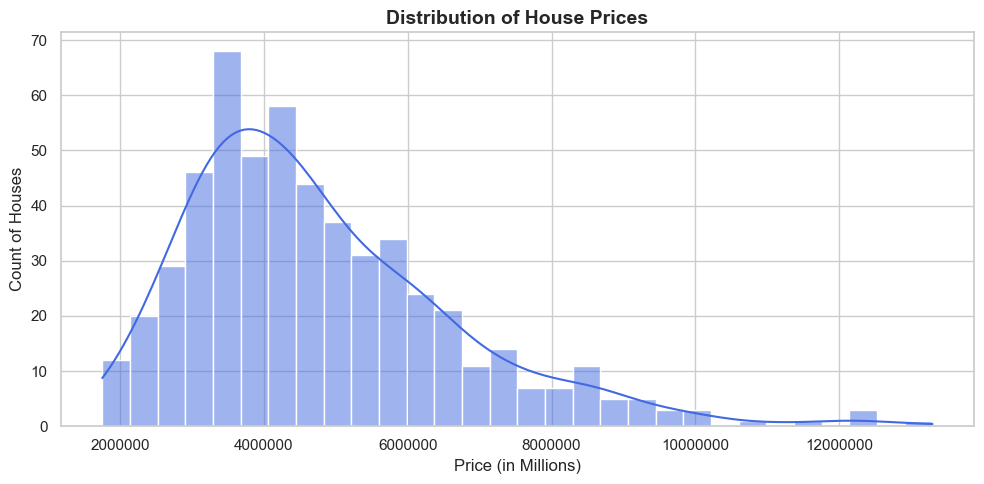

In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Automatically create the 'charts' folder if it doesn't exist yet
os.makedirs('charts', exist_ok=True)

# Set a clean, modern aesthetic for our charts
sns.set_theme(style="whitegrid")

# --- CHART 1: Histogram of House Prices ---
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (in Millions)', fontsize=12)
plt.ylabel('Count of Houses', fontsize=12)
# Format x-axis to show readable numbers instead of scientific notation
plt.ticklabel_format(style='plain', axis='x') 
plt.tight_layout()
plt.savefig('charts/price_distribution.png', dpi=300)
plt.show()

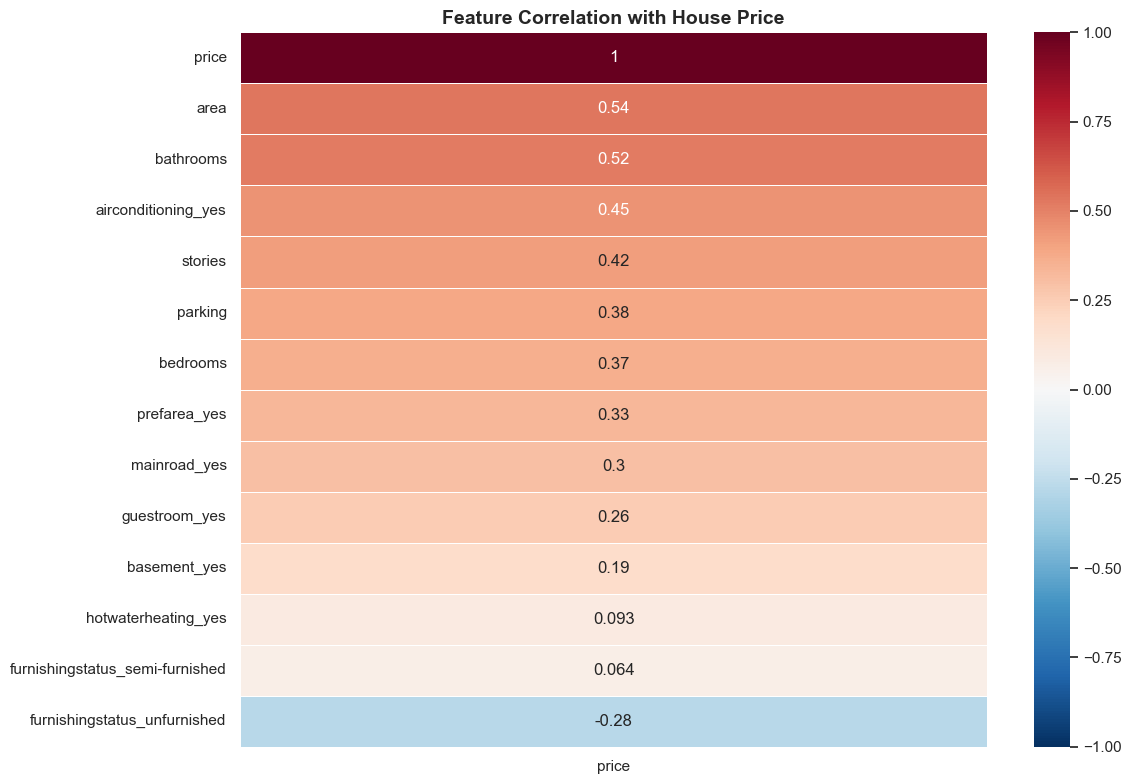

In [13]:
# --- CHART 2: Correlation Heatmap ---
plt.figure(figsize=(12, 8))
# We will look at how everything correlates specifically with 'price'
# Sorting makes it incredibly easy to see the top influencers at a glance
top_correlations = df_encoded.corr()[['price']].sort_values(by='price', ascending=False)

sns.heatmap(top_correlations, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation with House Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=300)
plt.show()

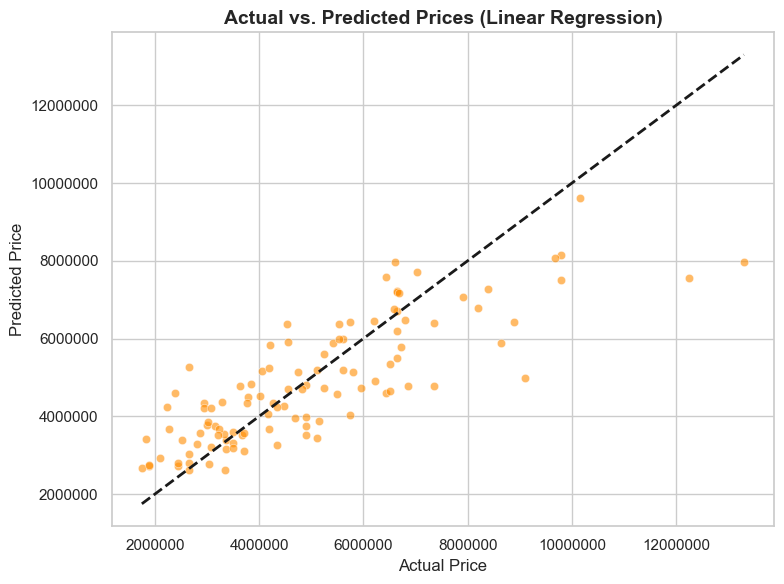

In [14]:
# --- CHART 3: Actual vs Predicted Prices (Our Choice!) ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=lr_preds, alpha=0.6, color='darkorange')
# Draw a perfect diagonal line. The closer the dots are to this line, the better the model!
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) 
plt.title('Actual vs. Predicted Prices (Linear Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png', dpi=300)
plt.show()

### Project Summary & Business Insights
Our analysis reveals that property **area** (square footage) has the single strongest influence on housing prices, closely followed by premium features like the number of bathrooms and the presence of air conditioning. Surprisingly, a simple Linear Regression model outperformed the more complex Random Forest Regressor, achieving an $R^2$ score of 65.3% while keeping an average prediction error (MAE) of approximately $970,043. This demonstrates that for smaller, cleaner datasets, simpler models often generalize better without overfitting. Based on these findings, it is highly recommended that real estate businesses optimize their valuation strategies by weighting square footage and climate control systems heavily over basic room counts when pricing new inventory.